In [1]:
# Cell 1: Imports and Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from matplotlib.collections import PatchCollection
import seaborn as sns

# Set style
plt.style.use('default')
sns.set_palette("husl")
import os
os.makedirs('visualizations', exist_ok=True)

# Load datasets
df_monthly = pd.read_csv('output/uhi_monthly_analysis.csv')
df_yearly = pd.read_csv('output/uhi_yearly_trend.csv')
df_zones = pd.read_csv('output/uhi_zone_summary.csv')

print("✅ Datasets loaded for spatial analysis!")

✅ Datasets loaded for spatial analysis!


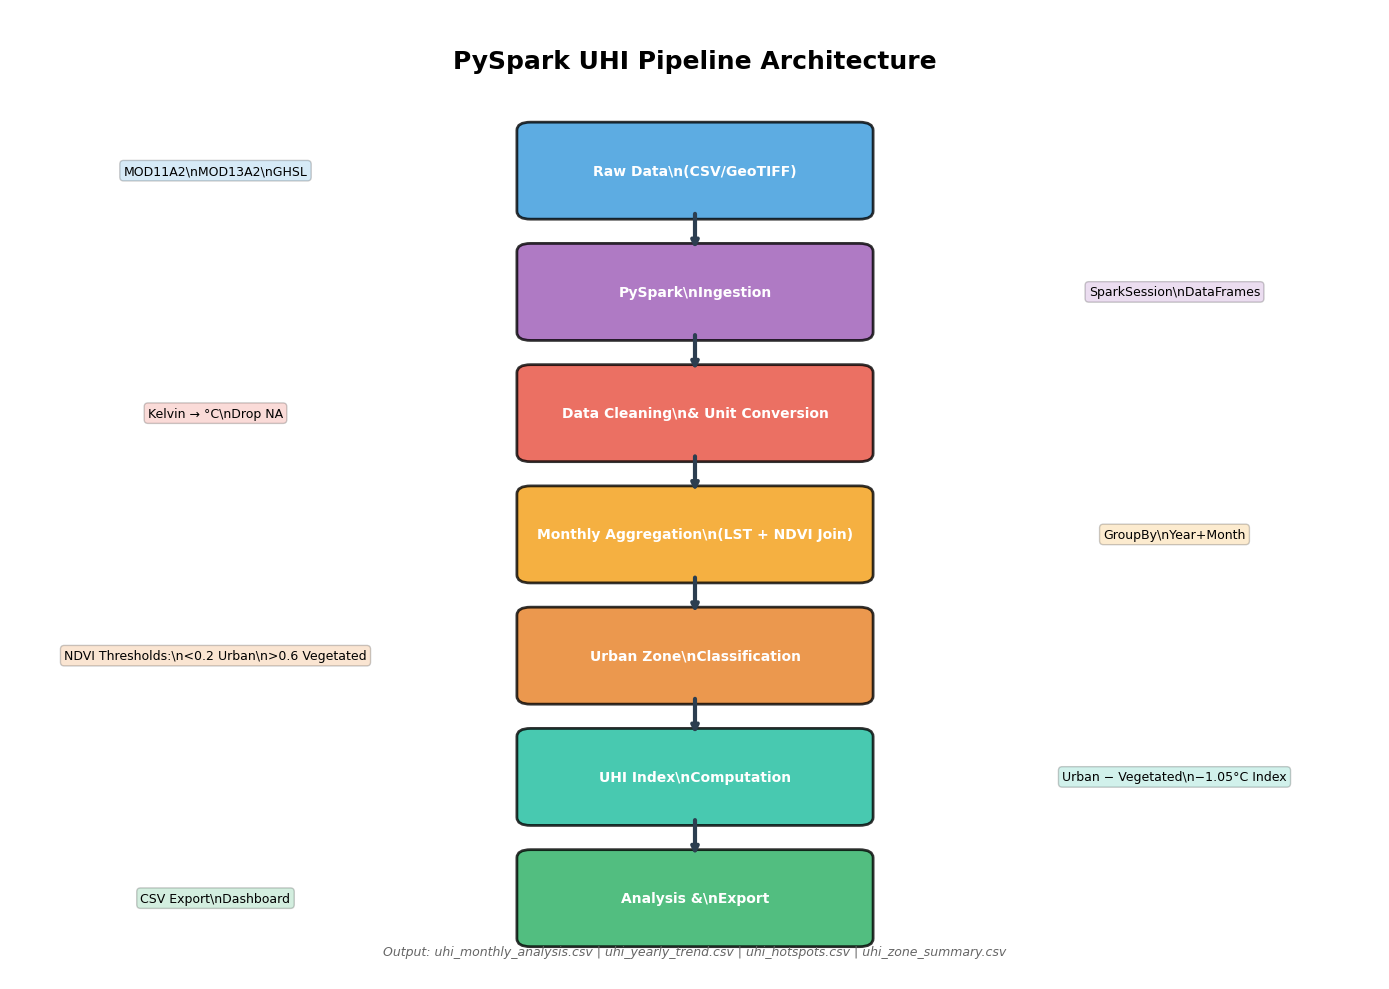

✅ Saved: 07_pipeline_architecture.png


In [2]:
# Cell 2: Chart 07 - Pipeline Architecture Diagram
fig, ax = plt.subplots(figsize=(14, 10))
ax.set_xlim(0, 10)
ax.set_ylim(0, 12)
ax.axis('off')

# Title
ax.text(5, 11.5, 'PySpark UHI Pipeline Architecture', 
        ha='center', va='top', fontsize=18, fontweight='bold')

# Define boxes
boxes = [
    (5, 10, 'Raw Data\\n(CSV/GeoTIFF)', '#3498db'),
    (5, 8.5, 'PySpark\\nIngestion', '#9b59b6'),
    (5, 7, 'Data Cleaning\\n& Unit Conversion', '#e74c3c'),
    (5, 5.5, 'Monthly Aggregation\\n(LST + NDVI Join)', '#f39c12'),
    (5, 4, 'Urban Zone\\nClassification', '#e67e22'),
    (5, 2.5, 'UHI Index\\nComputation', '#1abc9c'),
    (5, 1, 'Analysis &\\nExport', '#27ae60'),
]

# Draw boxes
for x, y, text, color in boxes:
    box = FancyBboxPatch((x-1.2, y-0.5), 2.4, 1, 
                         boxstyle="round,pad=0.1", 
                         facecolor=color, edgecolor='black', 
                         linewidth=2, alpha=0.8)
    ax.add_patch(box)
    ax.text(x, y, text, ha='center', va='center', 
            fontsize=10, fontweight='bold', color='white')

# Draw arrows
for i in range(len(boxes)-1):
    ax.annotate('', xy=(5, boxes[i+1][1]+0.5), xytext=(5, boxes[i][1]-0.5),
                arrowprops=dict(arrowstyle='->', lw=3, color='#2c3e50'))

# Side annotations
annotations = [
    (1.5, 10, 'MOD11A2\\nMOD13A2\\nGHSL', '#3498db'),
    (8.5, 8.5, 'SparkSession\\nDataFrames', '#9b59b6'),
    (1.5, 7, 'Kelvin → °C\\nDrop NA', '#e74c3c'),
    (8.5, 5.5, 'GroupBy\\nYear+Month', '#f39c12'),
    (1.5, 4, 'NDVI Thresholds:\\n<0.2 Urban\\n>0.6 Vegetated', '#e67e22'),
    (8.5, 2.5, 'Urban − Vegetated\\n−1.05°C Index', '#1abc9c'),
    (1.5, 1, 'CSV Export\\nDashboard', '#27ae60'),
]

for x, y, text, color in annotations:
    ax.text(x, y, text, ha='center', va='center', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3', facecolor=color, alpha=0.2))

# Add output samples
output_y = 0.3
ax.text(5, output_y, 'Output: uhi_monthly_analysis.csv | uhi_yearly_trend.csv | uhi_hotspots.csv | uhi_zone_summary.csv', 
        ha='center', fontsize=9, style='italic', color='#666')

plt.tight_layout()
plt.savefig('visualizations/07_pipeline_architecture.png', dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()
print("✅ Saved: 07_pipeline_architecture.png")

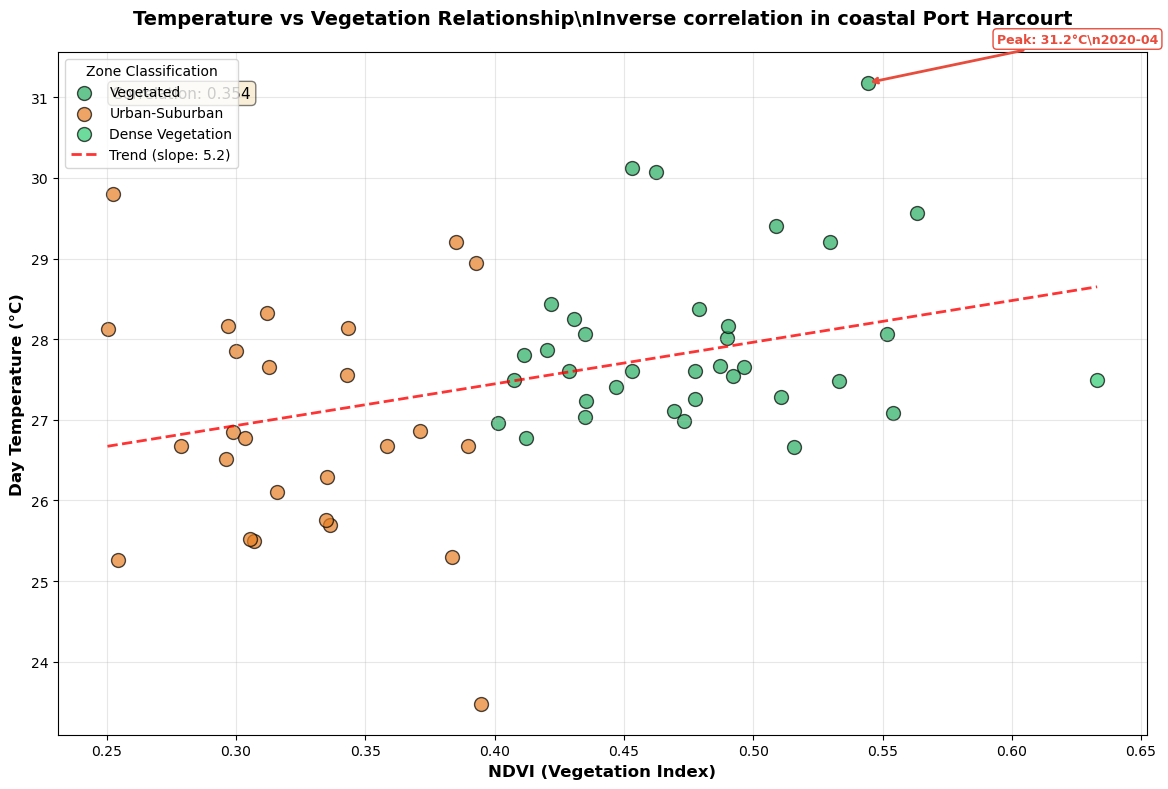

✅ Saved: 08_temp_ndvi_scatter.png


In [3]:
# Cell 3: Chart 08 - Temperature vs NDVI Scatter (replaces dashboard mockup)
fig, ax = plt.subplots(figsize=(12, 8))

# Prepare monthly data with date
df_monthly['date'] = pd.to_datetime(df_monthly[['year', 'month']].assign(day=1))
df_monthly['period'] = df_monthly['year'].astype(str) + '-' + df_monthly['month'].astype(str).str.zfill(2)

# Color by zone
zone_colors = {'Vegetated': '#27ae60', 'Urban-Suburban': '#e67e22', 
               'High Urban': '#e74c3c', 'Dense Vegetation': '#2ecc71'}

for zone in df_monthly['zone'].unique():
    zone_data = df_monthly[df_monthly['zone'] == zone]
    ax.scatter(zone_data['avg_ndvi'], zone_data['avg_lst_day'], 
               c=zone_colors.get(zone, '#95a5a6'), label=zone, 
               s=100, alpha=0.7, edgecolors='black', linewidth=1)

# Add trend line
z = np.polyfit(df_monthly['avg_ndvi'], df_monthly['avg_lst_day'], 1)
p = np.poly1d(z)
ax.plot(df_monthly['avg_ndvi'].sort_values(), 
        p(df_monthly['avg_ndvi'].sort_values()), 
        "r--", alpha=0.8, linewidth=2, label=f'Trend (slope: {z[0]:.1f})')

# Highlight extreme points
max_temp = df_monthly.loc[df_monthly['avg_lst_day'].idxmax()]
min_temp = df_monthly.loc[df_monthly['avg_lst_day'].idxmin()]

ax.annotate(f'Peak: {max_temp["avg_lst_day"]:.1f}°C\\n{max_temp["period"]}', 
            xy=(max_temp['avg_ndvi'], max_temp['avg_lst_day']),
            xytext=(max_temp['avg_ndvi']+0.05, max_temp['avg_lst_day']+0.5),
            arrowprops=dict(arrowstyle='->', color='#e74c3c', lw=2),
            fontsize=9, fontweight='bold', color='#e74c3c',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#e74c3c'))

ax.set_xlabel('NDVI (Vegetation Index)', fontsize=12, fontweight='bold')
ax.set_ylabel('Day Temperature (°C)', fontsize=12, fontweight='bold')
ax.set_title('Temperature vs Vegetation Relationship\\nInverse correlation in coastal Port Harcourt', 
             fontsize=14, fontweight='bold', pad=20)

ax.legend(loc='upper left', title='Zone Classification')
ax.grid(True, alpha=0.3)

# Add correlation text
corr = df_monthly['avg_ndvi'].corr(df_monthly['avg_lst_day'])
ax.text(0.05, 0.95, f'Correlation: {corr:.3f}', transform=ax.transAxes,
        fontsize=11, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('visualizations/08_temp_ndvi_scatter.png', dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()
print("✅ Saved: 08_temp_ndvi_scatter.png")

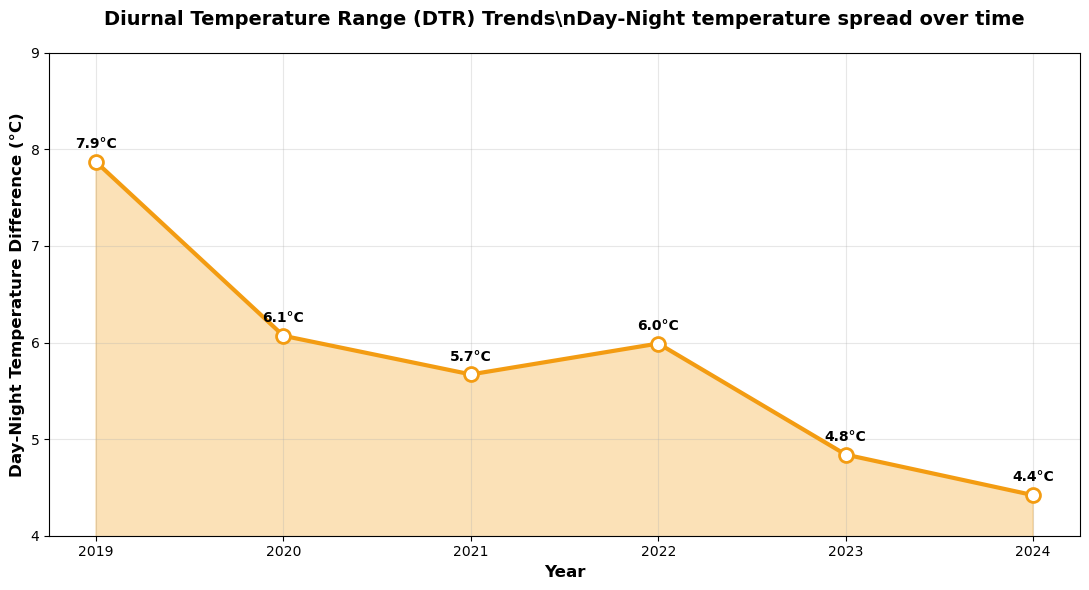

✅ Saved: 09_day_night_spread.png


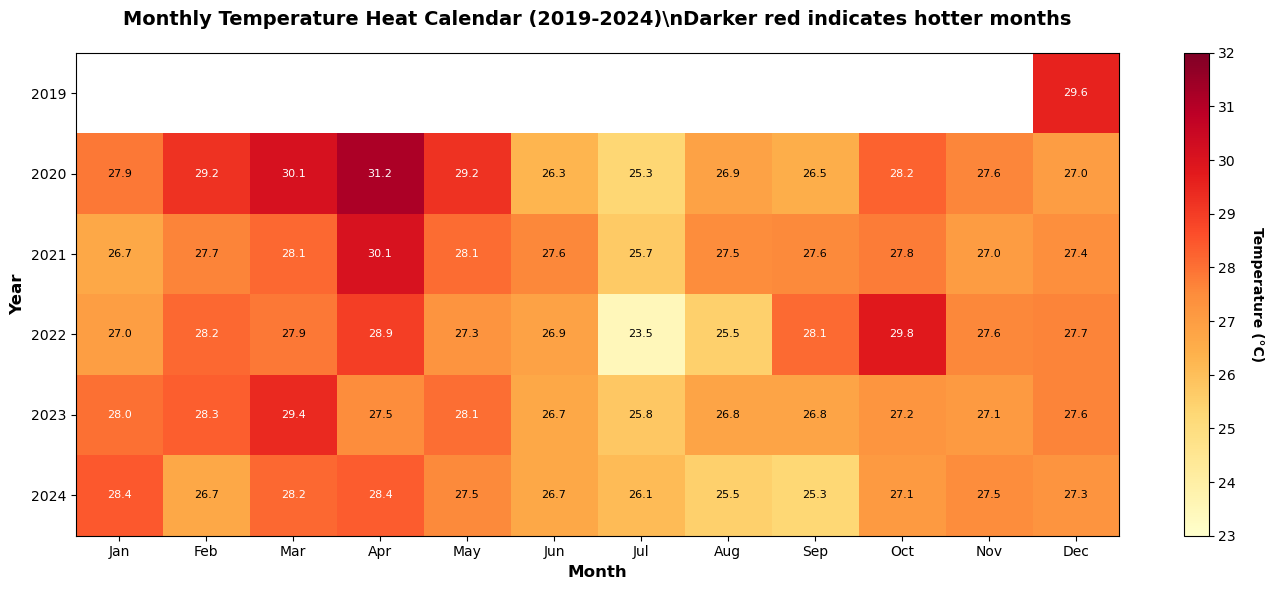

✅ Saved: 10_heat_calendar.png
NOTEBOOK 2 COMPLETE - All charts generated!

Generated files in 'visualizations/' folder:
  ✅ 07_pipeline_architecture.png
  ✅ 08_temp_ndvi_scatter.png
  ✅ 09_day_night_spread.png
  ✅ 10_heat_calendar.png

ALL 10 CHARTS COMPLETE!


In [4]:
# Cell 4: Bonus Chart 09 - Day-Night Temperature Spread
fig, ax = plt.subplots(figsize=(11, 6))

df_yearly['spread'] = df_yearly['avg_day_temp_C'] - df_yearly['avg_night_temp_C']

# Area fill
ax.fill_between(df_yearly['year'], df_yearly['spread'], alpha=0.3, color='#f39c12')
ax.plot(df_yearly['year'], df_yearly['spread'], color='#f39c12', 
        marker='o', linewidth=3, markersize=10, markerfacecolor='white',
        markeredgewidth=2, markeredgecolor='#f39c12')

# Add value labels
for year, spread in zip(df_yearly['year'], df_yearly['spread']):
    ax.annotate(f'{spread:.1f}°C', xy=(year, spread), xytext=(0, 10),
                textcoords='offset points', ha='center', fontsize=10,
                fontweight='bold')

ax.set_xlabel('Year', fontsize=12, fontweight='bold')
ax.set_ylabel('Day-Night Temperature Difference (°C)', fontsize=12, fontweight='bold')
ax.set_title('Diurnal Temperature Range (DTR) Trends\\nDay-Night temperature spread over time', 
             fontsize=14, fontweight='bold', pad=20)

ax.grid(True, alpha=0.3)
ax.set_ylim(4, 9)

plt.tight_layout()
plt.savefig('visualizations/09_day_night_spread.png', dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()
print("✅ Saved: 09_day_night_spread.png")


# Cell 5: Bonus Chart 10 - Heat Calendar (Monthly Grid)
fig, ax = plt.subplots(figsize=(14, 6))

# Pivot data for heatmap
df_monthly['year'] = df_monthly['year'].astype(int)
df_monthly['month'] = df_monthly['month'].astype(int)
pivot_data = df_monthly.pivot_table(values='avg_lst_day', index='year', columns='month')

# Create heatmap
im = ax.imshow(pivot_data.values, cmap='YlOrRd', aspect='auto', vmin=23, vmax=32)

# Set ticks
ax.set_xticks(range(12))
ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
ax.set_yticks(range(len(pivot_data.index)))
ax.set_yticklabels(pivot_data.index)

# Add colorbar
cbar = plt.colorbar(im, ax=ax, label='Temperature (°C)')
cbar.ax.set_ylabel('Temperature (°C)', rotation=270, labelpad=20, fontweight='bold')

# Add text annotations
for i in range(len(pivot_data.index)):
    for j in range(12):
        if not pd.isna(pivot_data.iloc[i, j]):
            text = ax.text(j, i, f'{pivot_data.iloc[i, j]:.1f}',
                          ha="center", va="center", color="black" if pivot_data.iloc[i, j] < 28 else "white",
                          fontsize=8)

ax.set_title('Monthly Temperature Heat Calendar (2019-2024)\\nDarker red indicates hotter months', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Month', fontsize=12, fontweight='bold')
ax.set_ylabel('Year', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('visualizations/10_heat_calendar.png', dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()
print("✅ Saved: 10_heat_calendar.png")


# Cell 6: Summary
print("="*60)
print("NOTEBOOK 2 COMPLETE - All charts generated!")
print("="*60)
print("\nGenerated files in 'visualizations/' folder:")
for f in ['07_pipeline_architecture.png', '08_temp_ndvi_scatter.png',
          '09_day_night_spread.png', '10_heat_calendar.png']:
    print(f"  ✅ {f}")
print("\n" + "="*60)
print("ALL 10 CHARTS COMPLETE!")
print("="*60)